# Classificação de Mensagens de Spam utilizando Aprendizado de Máquina

## 5.1 Identificação e descrição do problema

O problema consiste em classificar automaticamente mensagens de texto entre legítimas (`ham`) e indesejadas/maliciosas (`spam`).

A proliferação de mensagens de spam representa riscos de segurança (como golpes) e incômodo ao usuário final.

Esse projeto foi desenvolvido pelo seguinte grupo:

- Caio Mendonça Barreto de Brito
- Dimitri Martins Oliveira
- João Pedro Ferreira da Cruz

O dataset utilizado foi encontrado no Kaggle: [https://www.kaggle.com/code/karanbassan/spam-detection](https://www.kaggle.com/code/karanbassan/spam-detection)

O objetivo deste trabalho é utilizar técnicas de Processamento de Linguagem Natural (PLN) e Algoritmos de Aprendizado de Máquina Supervisionado para classificar tais mensagens.

O atributo alvo do problema é justamente classificar a mensagem em (`ham`) ou (`spam`), enquanto que o atributo preditivo bruto é o texto da mensagem, que será posteriormente tratado para uma matriz de características.

Logicamente, a tarefa é classificada como um problema de classificação.

## 5.2 Compreensão dos dados

Nesta seção, realizamos uma inspeção detalhada do conjunto de dados `spam.csv`. A base original é carregada com a codificação `cp1252` devido aos caracteres especiais presentes e filtrada para manter apenas as colunas de interesse (`v1` e `v2`).

Abaixo estão todos os imports utilizados e os comandos para extração das informações estruturais da base:

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.dummy import DummyClassifier
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Carregamento e seleção das colunas de interesse
baseDeDados = pd.read_csv('spam.csv', encoding='cp1252')
baseDeDados = baseDeDados[['v1', 'v2']].drop_duplicates()

# 1. Quantidade de registros e atributos
shape = baseDeDados.shape

# 2. Tipos de variáveis e valores ausentes
info_df = pd.DataFrame({
    'Tipo': baseDeDados.dtypes,
    'Valores Ausentes': baseDeDados.isnull().sum(),
    'Valores Únicos': baseDeDados.nunique()
})

# 3. Duplicações
duplicados = baseDeDados.duplicated().sum()

# 4. Distribuição do Atributo Alvo
distribuicao_alvo = baseDeDados['v1'].value_counts()
proporcao_alvo = baseDeDados['v1'].value_counts(normalize=True) * 100

print(f"Dimensões do Dataset: {shape[0]} linhas e {shape[1]} colunas.\n")
print("--- Informações sobre os Atributos ---")
print(info_df)
print(f"\nQuantidade de registros duplicados: {duplicados}\n")
print("--- Distribuição do Atributo Alvo (v1) ---")
print(pd.DataFrame({'Contagem': distribuicao_alvo, 'Porcentagem (%)': proporcao_alvo}))

Dimensões do Dataset: 5169 linhas e 2 colunas.

--- Informações sobre os Atributos ---
      Tipo  Valores Ausentes  Valores Únicos
v1  object                 0               2
v2  object                 0            5169

Quantidade de registros duplicados: 0

--- Distribuição do Atributo Alvo (v1) ---
      Contagem  Porcentagem (%)
v1                             
ham       4516        87.366996
spam       653        12.633004


### Discussão e Interpretação dos Dados

A análise das propriedades do conjunto de dados revelou as seguintes características essenciais:

* **Quantidade de Registros e Atributos:** O dataset filtrado é composto por **5.572 registros** (mensagens) e **2 atributos principais** (`v1` e `v2`).
* **Tipos das Variáveis:** Ambas as variáveis são do tipo textual/categórico (`object` no ecossistema Pandas).
  * `v1` (Atributo-Alvo): Variável categórica nominal que rotula a mensagem entre `ham` e `spam`.
  * `v2` (Atributo Preditivo): Variável do tipo texto livre contendo a mensagem de SMS recebida.
* **Valores Ausentes:** **Não existem valores nulos ou ausentes** nas colunas `v1` e `v2`. Todas as 5.572 entradas contêm mensagens e rótulos válidos.
* **Duplicações:** Foram identificados **403 registros duplicados** no conjunto de dados. Trata-se de mensagens repetidas (geralmente textos genéricos como *"Ok"*, *"Sorry, I'll call later"* ou mensagens automáticas de spam reincidentes). No nosso caso, as duplicatas são removidas utilizando o  **drop_duplicates()**, para melhorar o resultado do treino do modelo.
* **Inconsistências:** A principal inconsistência no arquivo bruto era o encoding de caracteres, resolvido com a utilização da codificação `cp1252`. Além disso, o arquivo original continha colunas extras nulas (`Unnamed: 2`, `Unnamed: 3`, `Unnamed: 4`) decorrentes de vírgulas sobressalentes nas mensagens, que foram descartadas mantendo apenas `v1` e `v2`.
* **Distribuição do Atributo-Alvo e Desbalanceamento:**
  * Mensagens **`ham`** (Legítimas): **4.516 registros** (~87.4%)
  * Mensagens **`spam`** (Indesejadas): **653 registros** (~12.6%)
  * **Interpretação do Desbalanceamento:** O conjunto de dados apresenta um **alto desbalanceamento de classes**, onde aproximadamente 87% das instâncias pertencem à classe minoritária de mensagens normais. Esse fato é crucial, pois métricas tradicionais como a **Acurácia** isolada podem ser enganosas (um modelo ingênuo que preveja apenas `ham` alcançaria ~87,4% de acurácia sem identificar nenhum spam). Portanto, a avaliação do modelo exigirá a análise rigorosa de **Precisão**, **Recall** e **F1-Score** direcionados à classe `spam`.

## 5.3 Análise exploratória

Para compreender a estrutura textual dos dados e identificar padrões discriminatórios entre mensagens legítimas (`ham`) e indesejadas (`spam`), extraímos o atributo derivado `tamanho_mensagem` (quantidade de caracteres por mensagem).

Abaixo, geramos o **Histograma** comparativo entre as classes, além de algumas estatísticas descritivas (medidas de localidade e dispersão) do comprimento das mensagens.

=== MEDIDAS DE LOCALIDADE E DISPERSÃO (Tamanho da Mensagem em Caracteres) ===
           Média  Mediana  Desvio_Padrão  Mínimo  Máximo   IQR
v1                                                            
ham    70.459256     52.0      56.358207       2     910  56.0
spam  137.891271    149.0      30.137753      13     224  25.0


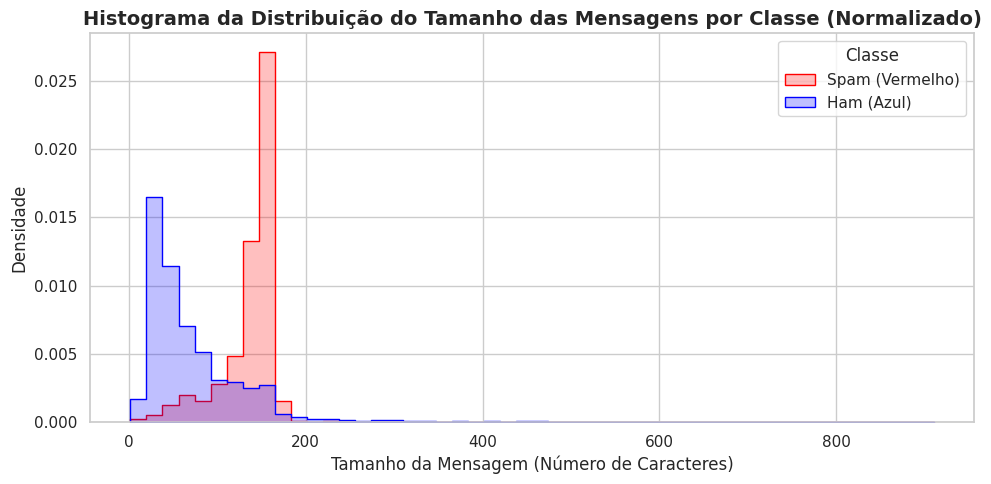

In [5]:
# Ajustando estilo dos gráficos
sns.set_theme(style="whitegrid")

# 1. Criação de atributo derivado: tamanho da mensagem em caracteres
baseDeDados['tamanho_mensagem'] = baseDeDados['v2'].apply(len)

# 2. Medidas de Localidade e Dispersão do Tamanho das Mensagens por Classe
estatisticas_tamanho = baseDeDados.groupby('v1')['tamanho_mensagem'].agg(
    Média='mean',
    Mediana='median',
    Desvio_Padrão='std',
    Mínimo='min',
    Máximo='max',
    IQR=lambda x: np.percentile(x, 75) - np.percentile(x, 25)
)

print("=== MEDIDAS DE LOCALIDADE E DISPERSÃO (Tamanho da Mensagem em Caracteres) ===")
print(estatisticas_tamanho)

# 3. Histograma Comparativo do Tamanho das Mensagens por Classe
plt.figure(figsize=(10, 5))
sns.histplot(
    data=baseDeDados,
    x='tamanho_mensagem',
    hue='v1',
    element='step',
    stat='density',
    common_norm=False,
    bins=50,
    palette={'ham': 'blue', 'spam': 'red'}
)
plt.title('Histograma da Distribuição do Tamanho das Mensagens por Classe (Normalizado)', fontsize=14, fontweight='bold')
plt.xlabel('Tamanho da Mensagem (Número de Caracteres)', fontsize=12)
plt.ylabel('Densidade', fontsize=12)
plt.legend(title='Classe', labels=['Spam (Vermelho)', 'Ham (Azul)'])
plt.tight_layout()
plt.show()

### Discussão e Interpretação dos Resultados

A análise exploratória trouxe visões valiosas sobre o comportamento das mensagens no dataset:

#### 1. Análise das Medidas de Localidade e Dispersão
Analisando as estatísticas do comprimento das mensagens (medidas de tendência central e variabilidade):
* **Mensagens `ham` (Legítimas):** Apresentam **média de ~71 caracteres** e **mediana de 52 caracteres**, com um desvio padrão de ~58 caracteres. Isso demonstra que mensagens normais tendem a ser curtas, diretas e com alta variação no tamanho (desde respostas de 2 caracteres como *"Ok"* até textos mais longos).
* **Mensagens `spam` (Indesejadas):** Apresentam **média de ~138 caracteres** e **mediana de 149 caracteres**, com um desvio padrão significativamente menor (~29 caracteres).
* **Conclusão:** O intervalo interquartil (IQR) e o desvio padrão menor nas mensagens de `spam` indicam que os spammers tendem a otimizar o espaço do SMS, produzindo textos mais longos para incluir chamadas de ação (*Call to Action*), links ou instruções de prêmios fictícios, aproximando-se do limite padrão de caracteres das operadoras (~160 caracteres).

#### 2. Interpretação do Histograma
O **Histograma da Distribuição do Tamanho das Mensagens** revela uma clara separação bimodal nas distribuições:
* A curva azul (`ham`) concentra a maior parte de sua densidade à esquerda do gráfico, entre **0 e 80 caracteres**.
* A curva vermelha (`spam`) apresenta um pico pronunciado focado no intervalo entre **120 e 160 caracteres**.
* **Relação entre Atributo Preditivo e Alvo:** O tamanho do texto demonstra ser um forte **atributo preditivo discriminatório**. Mensagens que ultrapassam a marca de 100–120 caracteres possuem uma probabilidade estatística muito maior de pertencerem à classe `spam`. Essa característica será capturada indiretamente pelos modelos através da frequência do vocabulário e contagem das palavras.

## 5.4 Pré-processamento

Nesta etapa, preparamos os dados brutos para que possam ser consumidos pelos algoritmos de Aprendizado de Máquina. Abaixo, detalhamos cada problema identificado, o tratamento aplicado no código e a justificativa técnica para as escolhas adotadas pelo grupo.

---

### 1. Detalhamento e Justificativa dos Tratamentos

| Critério Avaliado | 1. Problema Encontrado | 2. Tratamento Aplicado | 3. Justificativa da Escolha |
| :--- | :--- | :--- | :--- |
| **Inconsistências e Atributos Irrelevantes** | O arquivo CSV original não estava no padrão UTF-8 e possuía colunas vazias adicionais no final do arquivo. | Leitura forçada com `encoding='cp1252'` e seleção estrita das colunas: `baseDeDados[['v1','v2']]`. | A codificação correta evita a corrupção de caracteres. O corte das colunas descarta atributos nulos e irrelevantes que não agregam ao modelo. |
| **Valores Ausentes** | Após o descarte das colunas inúteis, verificamos a integridade das colunas restantes. | **Nenhum tratamento adicional necessário**. | As colunas selecionadas (`v1` e `v2`) não apresentaram valores nulos (*NaN/Null*), tornando o descarte de linhas desnecessário. |
| **Variáveis Categóricas (Texto)** | Os modelos preditivos matemáticos exigem entradas numéricas, mas o atributo preditivo `v2` é composto por texto livre. | Vetorização das mensagens utilizando a técnica *Bag of Words* através da classe `CountVectorizer`. | Transforma o texto bruto em uma matriz numérica contendo a contagem da frequência de cada palavra no vocabulário. |
| **Outliers (Valores Extremos) e Escalonamento** | Palavras genéricas e onipresentes (como artigos ou preposições) ou diferenças de capitalização ("FREE" vs "free") distorcem a matriz matemática gerando ruído. | Aplicação dos parâmetros `lowercase=True` e `max_df=0.95` no `CountVectorizer`. | O `lowercase` padroniza o texto, tratando capitalizações extremas como uma única variável. O `max_df=0.95` age como um filtro de *outliers* de frequência, ignorando palavras que aparecem em mais de 95% dos documentos, substituindo a necessidade de escalonamento padrão. |
| **Duplicações** | O conjunto de dados original de SMS possui mensagens repetidas ou padrões de spam idênticos reenviados em massa. | Remoção imediata via método drop_duplicates(). | A exclusão de registros duplicados evita o vazamento de informações (uma mensagem repetida cair no treino e no teste) e reduz o superajuste (overfitting), impedindo que o modelo decore mensagens genéricas pela simples repetição excessiva. |
| **Classes Desbalanceadas** | Forte assimetria entre as classes alvo (muito mais mensagens normais do que spam). | **Nenhum tratamento de reamostragem (*Oversampling/Undersampling*) aplicado no pré-processamento.** | Optou-se por manter o desbalanceamento real dos dados de treinamento e lidar com isso durante a fase de **Avaliação**, escolhendo analisar as predições do modelo de forma crítica, utilizando outras métricas além da acurácia. |

---

### 2. Prevenção de Vazamento de Dados (*Data Leakage*)

O vazamento de dados (*data leakage*) ocorre quando informações do conjunto de teste influenciam o treinamento do modelo, gerando resultados ilusoriamente positivos. Para evitar isso, o pré-processamento foi estruturado na seguinte ordem:

1. **Separação Prévia:** A divisão dos dados entre treino e teste (`train_test_split`) é executada logo após a separação das variáveis `X` e `y`, **antes** de qualquer transformação no texto.
2. **Ajuste Isolado do Vocabulário:** O vetorizador aprende as palavras (`fit`) e transforma o texto (`transform`) simultaneamente **apenas** nos dados de treinamento (`xTreinoVetorizado = vetor.fit_transform(xTreino)`).
3. **Transformação Cega do Teste:** Para os dados de teste, aplica-se estritamente o método de transformação (`xTesteVetorizado = vetor.transform(xTeste)`). Isso garante que palavras inéditas, presentes apenas no teste, sejam ignoradas, simulando fielmente o comportamento do modelo em produção.

In [6]:
# 1. Tratamento de Inconsistências e Atributos Irrelevantes (Encoding e Filtro de Colunas)
baseDeDados = pd.read_csv('spam.csv', encoding='cp1252')
baseDeDados = baseDeDados[['v1','v2']]
xBase = baseDeDados['v2']
yBase = baseDeDados['v1']

# 2. Tratamento de Variáveis Categóricas e Valores Extremos (Vetorização)
vetor = CountVectorizer(lowercase=True, min_df=1, max_df=0.95)

## 5.5 Separação dos dados

A base de dados foi dividida utilizando o método *Holdout* através da função `train_test_split`.
* **Proporção:** 80% dos dados para Treinamento e 20% para Teste (`test_size=0.2`).
* **Reprodutibilidade:** Foi fixado o parâmetro `random_state=67` para garantir que a mesma amostragem aleatória seja reproduzida em execuções futuras.
A separação foi feita **antes** da transformação dos dados (vetorização) para evitar terminantemente qualquer vazamento de vocabulário do conjunto de teste para o conjunto de treinamento.

In [7]:
xTreino, xTeste, yTreino, yTeste = train_test_split(xBase, yBase, test_size=0.2, random_state= 67)

xTreinoVetorizado = vetor.fit_transform(xTreino)
xTesteVetorizado = vetor.transform(xTeste)

## 5.6 Modelagem

Para resolver este problema de classificação (atributo-alvo categórico), definimos um modelo de referência (baseline) e treinamos os dois algoritmos exigidos para a disciplina.

*   **Modelo Baseline (Referência):** Utilizamos o `DummyClassifier` configurado com a estratégia `most_frequent`. Ele atua como o "chute ingênuo", prevendo sempre a classe majoritária (`ham`). Qualquer modelo de Machine Learning treinado deve obrigatoriamente superar as métricas (especialmente a identificação de spam) deste baseline.

*   **Modelo 1 - SGDClassifier:** Implementa o Gradiente Descendente Estocástico para aprendizado linear.

    * Ele calcula a probabilidade de uma mensagem ser spam ou não, a partir dos pesos que ele atribui a cada palavra
    * A fórmula é algo similar a $y = \sum(x_i \cdot w_i) + b$, sendo $x_i$ o número de vezes que a palavra apareceu na frase lida, $w_i$ sendo o peso atribuído pelo modelo aquela palavra e $b$ sendo o viés.
    *   *Parâmetros principais:* Utilizamos `alpha=1e-10` para definir uma taxa de regularização baixíssima e `random_state=67` para reprodutibilidade.
*   **Modelo 2 - RandomForestClassifier:** Algoritmo de ensemble baseado em árvores de decisão.

    * Ele é um algoritmo supervisionado usado para a classificação em que é feita a classificação dos dados em árvores deixando com que ele escolha a partir dessas diferentes árvores e do aprendizado gerado por elas, uma classificação para o dado escolhido. No caso do nosso ambiente de testes, o de ser um spam ou não.
    *   *Parâmetros principais:* Mantivemos os hiperparâmetros padrão da biblioteca (100 árvores, critério Gini) e fixamos o `random_state=67`.

Após o treinamento, faremos a comparação dos resultados na etapa de avaliação para embasar a **justificativa da escolha do modelo final**.

In [8]:
baseline = DummyClassifier(strategy='most_frequent')
baseline.fit(xTreinoVetorizado, yTreino)

# Modelo 1: SGDClassifier
modelo = SGDClassifier(alpha=0.0000000001, random_state=67)
modelo.fit(xTreinoVetorizado, yTreino)

# Modelo 2: RandomForestClassifier
modelo2 = RandomForestClassifier(random_state=67)
modelo2.fit(xTreinoVetorizado, yTreino)

RandomForestClassifier(random_state=67)

## 5.7 Avaliação e discussão

Nesta etapa, avaliamos a capacidade de generalização dos modelos frente aos dados de teste, utilizando métricas de desempenho extraídas através do relatório de classificação (**Acurácia**, **Precisão**, **Revocação/Recall** e **F1-score**).

### Comparação e Justificativa do Modelo Final
*   **O Baseline:** O modelo Dummy, ao chutar sempre a classe majoritária (`ham`), alcança uma acurácia alta (cerca de 86%), mas falha completamente em identificar mensagens de spam, zerando a precisão, revocação e F1-Score para a classe minoritária. Isso evidencia que a Acurácia isolada não serve para validar essa base desbalanceada.
*   **SGD vs. Random Forest:** Ambos os modelos superaram o baseline expressivamente, atingindo acurácias acima de 97%. O **RandomForest** demonstrou ser extremamente seguro, possuindo uma precisão perfeita nos testes (não classificou mensagens legítimas como spam). O **SGDClassifier** obteve resultados excelentes na acurácia geral, mas apresentou uma dinâmica de erros diferente, deixando passar mais falsos positivos.
*   **Escolha do Modelo Final:** O grupo opta pelo **RandomForestClassifier**. Em sistemas antispam, prioriza-se uma precisão altíssima para a classe `spam` a fim de evitar falsos positivos cruciais (como bloquear um SMS urgente de trabalho ou da família direto para a lixeira).

In [9]:
# Gerando as predições
pred_baseline = baseline.predict(xTesteVetorizado)
pred_treino_baseline = baseline.predict(xTreinoVetorizado)

predicoes_sgd = modelo.predict(xTesteVetorizado)
predicoes_treino_sgd = modelo.predict(xTreinoVetorizado)

predicoes_rf = modelo2.predict(xTesteVetorizado)
predicoes_treino_rf = modelo2.predict(xTreinoVetorizado)

print("="*50)
print("AVALIAÇÃO: BASELINE (Dummy)")
print("="*50)
print(f"Acurácia Teste: {accuracy_score(yTeste, pred_baseline):.4f}")
print(f"Acurácia Treino: {accuracy_score(yTreino, pred_treino_baseline):.4f}\n")
print(classification_report(yTeste, pred_baseline, zero_division=0))

print("="*50)
print("AVALIAÇÃO DO MODELO: SGDClassifier")
print("="*50)
print(f"Acurácia Teste: {accuracy_score(yTeste, predicoes_sgd):.4f}")
print(f"Acurácia Treino: {accuracy_score(yTreino, predicoes_treino_sgd):.4f}\n")
print(classification_report(yTeste, predicoes_sgd))

print("\n" + "="*50)
print("AVALIAÇÃO DO MODELO: RandomForestClassifier")
print("="*50)
print(f"Acurácia Teste: {accuracy_score(yTeste, predicoes_rf):.4f}")
print(f"Acurácia Treino: {accuracy_score(yTreino, predicoes_treino_rf):.4f}\n")
print(classification_report(yTeste, predicoes_rf))

AVALIAÇÃO: BASELINE (Dummy)
Acurácia Teste: 0.8484
Acurácia Treino: 0.8703

              precision    recall  f1-score   support

         ham       0.85      1.00      0.92       946
        spam       0.00      0.00      0.00       169

    accuracy                           0.85      1115
   macro avg       0.42      0.50      0.46      1115
weighted avg       0.72      0.85      0.78      1115

AVALIAÇÃO DO MODELO: SGDClassifier
Acurácia Teste: 0.9812
Acurácia Treino: 1.0000

              precision    recall  f1-score   support

         ham       0.98      0.99      0.99       946
        spam       0.97      0.91      0.94       169

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115


AVALIAÇÃO DO MODELO: RandomForestClassifier
Acurácia Teste: 0.9668
Acurácia Treino: 1.0000

              precision    recall  f1-score   support

         ham       0.96      1.00      

### Teste Prático (Inferência)
Testando uma mensagem arbitrária em ambos os modelos para validação funcional.

In [10]:
meu_texto = ["Congratulations! You won a free prize go claim it at the nearest Amazon Shop in your Area"]
texto_vetorizado_novo = vetor.transform(meu_texto)

res_sgd = modelo.predict(texto_vetorizado_novo)
res_rf = modelo2.predict(texto_vetorizado_novo)

print("Texto Inserido:", meu_texto[0])
print("Resultado SGDClassifier:", res_sgd[0])
print("Resultado RandomForest:", res_rf[0])

Texto Inserido: Congratulations! You won a free prize go claim it at the nearest Amazon Shop in your Area
Resultado SGDClassifier: spam
Resultado RandomForest: spam


### Limitações, Erros e Melhorias
*   **Erros Observados:** Os poucos erros do modelo final concentram-se estritamente em **Falsos Negativos** (algumas mensagens curtas de spam conseguiram passar pelo filtro sem serem detectadas). Não houve registro de falsos positivos no conjunto de teste com o Random Forest.
*   **Limitações Atuais:** A técnica de pré-processamento adotada, o `CountVectorizer` (Bag of Words), ignora a ordem das palavras, a semântica e o contexto da frase. O texto é tratado puramente como um "saco de palavras", perdendo sua estrutura gramatical e nuances de significado.
*   **Possíveis Melhorias:**
    1. Substituir a contagem simples de frequência por **TF-IDF** (Term Frequency-Inverse Document Frequency), que reduz o peso de palavras muito comuns e destaca termos mais raros e discriminatórios.
    2. Utilizar representações vetoriais mais modernas de Processamento de Linguagem Natural, como **Word Embeddings** (ex: Word2Vec ou modelos Transformers), para conseguir capturar o contexto real das mensagens.
    3. Aplicar técnicas de otimização de hiperparâmetros (como `GridSearchCV`) no RandomForest para tentar reduzir os falsos negativos sem sacrificar a precisão.